# 00 — Introduction to single-nucleus RNA-seq data and AnnData

**Series:** SEA-AD single-nucleus multiome, taught with `scanpy`

This is your first contact with the data type. The goal of this notebook is
purely conceptual orientation — by the end you should be able to look at any
`.h5ad` file and know what you're looking at.

## What is single-nucleus RNA-seq (snRNA-seq)?

In bulk RNA-seq you grind up a piece of tissue and measure average gene
expression across millions of cells at once. In **single-cell/single-nucleus**
RNA-seq you instead measure gene expression **separately for each individual
cell (or nucleus)**. The SEA-AD dataset we're using is *single-nucleus*
specifically: the tissue is frozen postmortem brain, so instead of dissociating
intact whole cells, the assay isolates individual **nuclei** and sequences the
RNA captured inside each one. This matters biologically — nuclei contain much
less mitochondrial RNA than whole cells (mitochondria live in the cytoplasm,
outside the nucleus), which is why you'll see very low "percent mitochondrial"
values later, unlike in classic single-cell datasets.

The experimental technology here is 10x Genomics Chromium. Practically, this
means:
- Each nucleus gets tagged with a unique DNA **barcode** during library prep.
- Every mRNA molecule inside that nucleus gets its own random **UMI**
  (Unique Molecular Identifier) tag before PCR amplification.
- After sequencing, reads are grouped by barcode (= which nucleus) and
  deduplicated by UMI (so PCR copies of the same original molecule count
  once, not N times).
- The result is a **count matrix**: for every (nucleus, gene) pair, an
  integer = the number of *distinct original mRNA molecules* of that gene
  detected in that nucleus. This is the "UMI count."

Typical numbers: thousands of genes detected per nucleus, out of ~36,000
annotated genes/features, with total UMI counts per nucleus ranging from a
few hundred to tens of thousands.

## Why is the matrix sparse?

Most genes are not expressed in most cell types, and even expressed genes
are sampled incompletely (sequencing only captures a fraction of the RNA
molecules that were actually in the nucleus — this is called "dropout").
So the vast majority of (nucleus, gene) entries in the count matrix are
exactly zero. Storing this as a dense matrix would waste enormous amounts of
memory; instead scanpy/anndata store it as a **sparse matrix** (usually
`scipy.sparse.csr_matrix`), which only stores the nonzero entries and their
positions. We'll measure the actual sparsity below — expect >90% zeros.

## What is an `AnnData` object?

`AnnData` ("Annotated Data") is the core data structure of the scanpy/anndata
Python ecosystem — the Python-native equivalent of Seurat objects in R.
It bundles the count matrix together with all of its metadata in one object,
so operations stay aligned automatically. The main pieces:

| Slot | Shape | What it holds |
|---|---|---|
| `.X` | (n_obs, n_vars) | The main data matrix (nuclei × genes) |
| `.obs` | (n_obs, ...) | Per-nucleus metadata (a pandas DataFrame): QC metrics, donor ID, cell type labels, etc. |
| `.var` | (n_vars, ...) | Per-gene metadata (a pandas DataFrame): gene IDs, chromosome, etc. |
| `.obsm` | (n_obs, k) | Multi-dimensional per-nucleus arrays: PCA/UMAP coordinates, etc. |
| `.varm` | (n_vars, k) | Multi-dimensional per-gene arrays (less commonly used) |
| `.layers` | (n_obs, n_vars) | Alternative versions of the data matrix with the same shape as `.X` — e.g. raw counts vs. normalized values |
| `.uns` | dict | Unstructured metadata: colors, parameters, free-form notes |

`n_obs` = number of observations = nuclei. `n_vars` = number of variables =
genes. This "obs = rows, var = columns" convention is the opposite of a lot
of bioinformatics tradition (genes-as-rows), but it matches how you'd set up
any other ML dataset: **rows are samples, columns are features** — here,
each nucleus is a sample and each gene is a feature. That's exactly why this
format plays nicely with scikit-learn-style workflows.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

# DATA_DIR points at the already-downloaded SEA-AD data prepared for the
# companion R/Seurat project. We read directly from there rather than
# copying ~7.4GB into this repo.
DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
RNA_DIR = f"{DATA_DIR}/rna"
ATAC_DIR = f"{DATA_DIR}/atac"

DONOR_IDS = [
    "H20.33.001", "H20.33.002", "H20.33.004", "H20.33.005",
    "H20.33.012", "H20.33.013", "H20.33.017", "H21.33.003",
]

## Loading one donor's RNA data

We'll start with a single donor (H20.33.001) to keep things fast and
manageable. `sc.read_h5ad()` reads the file directly — no custom parsing
needed, because `.h5ad` is anndata's *native* on-disk format (an HDF5 file
with a specific internal layout). This is one of the nice things about
working in Python for this data type: the R/Seurat side of this project had
to write a from-scratch h5ad reader, because R has no native AnnData support.

In [2]:
donor = "H20.33.001"
adata = sc.read_h5ad(f"{RNA_DIR}/{donor}_RNAseq_final-nuclei.h5ad")
adata

AnnData object with n_obs × n_vars = 19297 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in mont

That summary printout is the fastest way to orient yourself in any AnnData
object: shape, then a listing of what's in `obs`, `var`, `uns`, `obsm`,
`layers`. Let's pull out the pieces explicitly.

In [3]:
print(f"n_obs (nuclei) = {adata.n_obs:,}")
print(f"n_vars (genes) = {adata.n_vars:,}")
print(f"X matrix type  = {type(adata.X)}")
print(f"X dtype        = {adata.X.dtype}")

n_obs (nuclei) = 19,297
n_vars (genes) = 36,601
X matrix type  = <class 'scipy.sparse._csr.csr_matrix'>
X dtype        = float64


### A subtlety specific to this dataset: `.X` is already transformed

SEA-AD ships `.X` already **normalized and log-transformed** (we'll learn
exactly what that means in notebook 02) — you can see this recorded in
`adata.uns["X_normalization"]`. The **raw UMI counts** — the thing described
above, one integer per (nucleus, gene) — are preserved separately in
`adata.layers["UMIs"]`. This is a common convention: keep `.X` as "the
matrix you'd plot/cluster with right now" while stashing raw counts in a
layer for anyone who wants to redo normalization themselves. In notebooks
01–02 we will deliberately restart from `layers["UMIs"]` and run our own QC
and normalization from scratch, both so you see every step and so our
thresholds are transparent and reproducible.

In [4]:
print("X_normalization (uns):", adata.uns.get("X_normalization"))
print()
print("X[:5, :5] (already log-normalized) as a dense peek:")
print(adata.X[:5, :5].toarray())
print()
print("layers['UMIs'][:5, :5] (raw integer UMI counts) as a dense peek:")
print(adata.layers["UMIs"][:5, :5].toarray())

X_normalization (uns): ln(UP10K+1)

X[:5, :5] (already log-normalized) as a dense peek:
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.04301368 0.        ]
 [0.         0.         0.         0.         0.        ]]

layers['UMIs'][:5, :5] (raw integer UMI counts) as a dense peek:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]]


### Measuring sparsity

Let's confirm the "mostly zeros" claim quantitatively, using the raw counts
layer.

In [5]:
raw = adata.layers["UMIs"]
n_entries = raw.shape[0] * raw.shape[1]
n_nonzero = raw.nnz
sparsity = 1 - n_nonzero / n_entries

print(f"Total matrix entries : {n_entries:,}")
print(f"Nonzero entries      : {n_nonzero:,}")
print(f"Sparsity (% zeros)   : {sparsity:.2%}")
print(f"Dense memory would be: {n_entries * 8 / 1e9:.2f} GB (float64)")
print(f"Sparse memory is     : {(raw.data.nbytes + raw.indices.nbytes + raw.indptr.nbytes) / 1e9:.3f} GB")

Total matrix entries : 706,289,497
Nonzero entries      : 114,512,596
Sparsity (% zeros)   : 83.79%
Dense memory would be: 5.65 GB (float64)
Sparse memory is     : 1.374 GB


That's roughly a >10x memory saving from using a sparse matrix — and this is
a *small* dataset by single-cell standards (one donor, ~19k nuclei). At
atlas scale (millions of cells) dense storage simply isn't an option.

## Exploring `.obs` — per-nucleus metadata

`.obs` is a pandas DataFrame, one row per nucleus, indexed by barcode. SEA-AD
packs a *lot* of columns in here: donor clinical metadata (repeated on every
row for that donor), 10x sequencing QC metrics, and SEA-AD's own reference
cell-type calls. Let's look at row count and a few columns that matter for
this series.

In [6]:
print(f".obs shape: {adata.obs.shape}")
print(f"\nFirst 5 barcodes (the .obs index):")
print(adata.obs.index[:5].tolist())
print(f"\nTotal number of .obs columns: {adata.obs.shape[1]}")

.obs shape: (19297, 130)

First 5 barcodes (the .obs index):
['AAACCCAAGAGAGCAA-L8TX_210318_01_D05-1142430392', 'AAACCCAAGCAATTCC-L8TX_210318_01_D05-1142430392', 'AAACCCACAATACAGA-L8TX_210318_01_D05-1142430392', 'AAACCCACACGCTGAC-L8TX_210318_01_D05-1142430392', 'AAACCCACATCCTGTC-L8TX_210318_01_D05-1142430392']

Total number of .obs columns: 130


Columns we'll come back to repeatedly in this series:
- **`method`** — which 10x protocol produced this nucleus. Some nuclei were
  profiled with RNA only (`10Xv3.1`), others with paired RNA+ATAC
  (`10xMulti`, the true "multiome" nuclei). Only `10xMulti` rows have a
  matching nucleus in the ATAC file.
- **`Class`** / **`Subclass`** / **`Supertype`** — SEA-AD's own reference
  cell-type annotation, at increasing resolution. This is genuine ground
  truth we can validate our own clustering against later.
- **`Doublet score`** — SEA-AD's precomputed estimate of how likely this
  "nucleus" is actually two nuclei captured together (see notebook 01).
- **`Fraction mitochondrial UMIs`** — QC metric, expected to be very low
  here because these are nuclei, not whole cells.
- **`Overall AD neuropathological Change`**, **`Braak`**, **`Thal`**,
  **`CERAD score`** — donor-level Alzheimer's pathology staging (notebook 04).

In [7]:
print("method (protocol) breakdown for this donor:")
print(adata.obs["method"].value_counts())
print()
print("Class (coarse cell type) breakdown:")
print(adata.obs["Class"].value_counts())

method (protocol) breakdown for this donor:
method
10Xv3.1     14644
10xMulti     4653
Name: count, dtype: int64

Class (coarse cell type) breakdown:
Class
Neuronal: Glutamatergic        12044
Neuronal: GABAergic             4013
Non-neuronal and Non-neural     3240
Name: count, dtype: int64


## Exploring `.var` — per-gene metadata

`.var` is the column-metadata counterpart: one row per gene, indexed by gene
symbol.

In [8]:
adata.var.head()

,gene_ids,feature_types,genome
index,,,
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38


In [9]:
print(f".var shape: {adata.var.shape}")
print(f"feature_types values: {adata.var['feature_types'].unique().tolist()}")
print(f"genome build: {adata.var['genome'].unique().tolist()}")

.var shape: (36601, 3)
feature_types values: ['Gene Expression']
genome build: ['GRCh38']


## `.obsm` and `.uns`

`.obsm` holds per-nucleus multi-dimensional arrays — here, SEA-AD's own
precomputed low-dimensional embeddings (scVI latent space and a UMAP layout).
We will compute our *own* PCA/UMAP from scratch in notebook 02 rather than
reusing these, so you see every step of the pipeline — but it's useful to
know they exist and roughly what shape to expect.

In [10]:
for key, arr in adata.obsm.items():
    print(f"obsm['{key}']: shape {arr.shape}")

print()
print("A few uns keys (free-form metadata):")
for key in list(adata.uns.keys()):
    print(" -", key)

obsm['X_scVI']: shape (19297, 20)
obsm['X_umap']: shape (19297, 2)

A few uns keys (free-form metadata):
 - Brain Region_colors
 - Great Apes Metadata
 - Subclass_colors
 - Supertype_colors
 - UW Clinical Metadata
 - X_normalization
 - batch_condition
 - default_embedding
 - title


## First plots: what does a nucleus "look like" numerically?

Two of the most basic per-nucleus QC numbers are:
- **total UMI counts** — how many mRNA molecules were captured, summed
  across all genes
- **number of genes detected** — how many distinct genes had >=1 UMI

These aren't biological signal by themselves, but they're the first thing
you always look at with any new single-cell dataset, because they tell you
about capture quality and set up the QC filtering we'll do properly in
notebook 01.

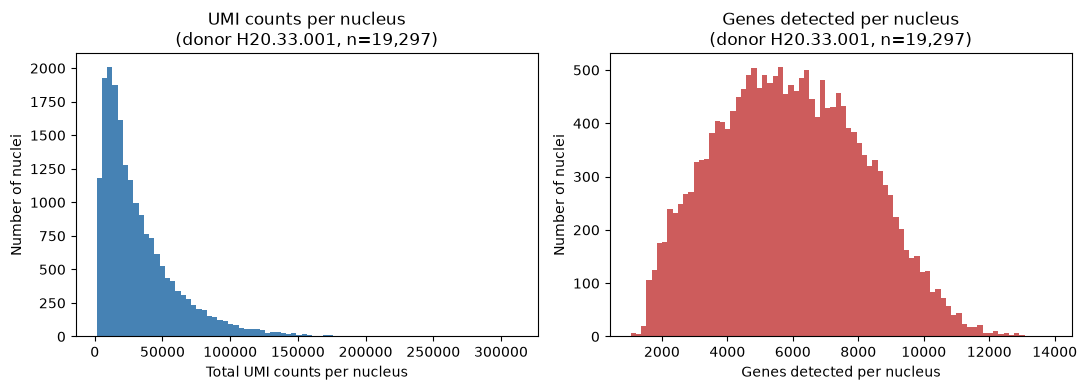

Median UMI counts/nucleus : 23,900
Median genes/nucleus      : 5,859


In [11]:
counts_per_nucleus = np.asarray(raw.sum(axis=1)).flatten()
genes_per_nucleus = np.asarray((raw > 0).sum(axis=1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(counts_per_nucleus, bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Total UMI counts per nucleus")
axes[0].set_ylabel("Number of nuclei")
axes[0].set_title(f"UMI counts per nucleus\n(donor {donor}, n={adata.n_obs:,})")

axes[1].hist(genes_per_nucleus, bins=80, color="indianred", edgecolor="none")
axes[1].set_xlabel("Genes detected per nucleus")
axes[1].set_ylabel("Number of nuclei")
axes[1].set_title(f"Genes detected per nucleus\n(donor {donor}, n={adata.n_obs:,})")

plt.tight_layout()
plt.show()

print(f"Median UMI counts/nucleus : {np.median(counts_per_nucleus):,.0f}")
print(f"Median genes/nucleus      : {np.median(genes_per_nucleus):,.0f}")

Both distributions are right-skewed — most nuclei cluster around a typical
depth, with a long tail of high-count nuclei (which can include
doublets/multiplets, more on this in notebook 01) and a low-count shoulder
(empty droplets / degraded nuclei, filtered out in notebook 01).

Note also the **relationship** between the two: genes detected and total
counts are correlated but not identical — a nucleus can have high counts
concentrated in few highly-expressed genes, or lower counts spread across
many genes.

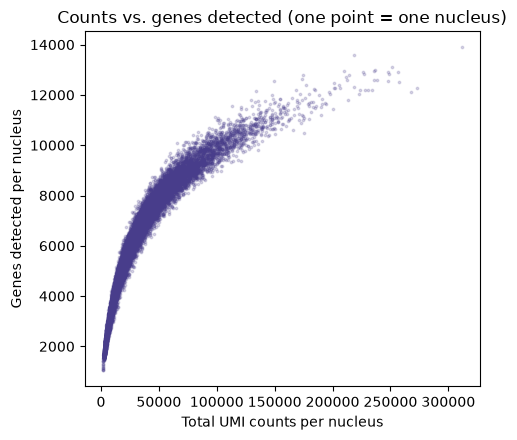

In [12]:
plt.figure(figsize=(5, 4.5))
plt.scatter(counts_per_nucleus, genes_per_nucleus, s=3, alpha=0.2, color="darkslateblue")
plt.xlabel("Total UMI counts per nucleus")
plt.ylabel("Genes detected per nucleus")
plt.title("Counts vs. genes detected (one point = one nucleus)")
plt.tight_layout()
plt.show()

## Recap

- snRNA-seq gives you a **nuclei × genes** count matrix: one UMI count per
  (nucleus, gene) pair, representing distinct mRNA molecules captured.
- The matrix is **sparse** (mostly zeros) — anndata stores it efficiently
  as a `scipy.sparse` matrix.
- `AnnData` bundles that matrix (`.X`, plus alternates in `.layers`) with
  row metadata (`.obs`, per nucleus), column metadata (`.var`, per gene),
  embeddings (`.obsm`), and free-form metadata (`.uns`) — all kept aligned.
- This particular dataset ships pre-normalized `.X` plus raw counts in
  `layers["UMIs"]`; we'll rebuild the pipeline from raw counts ourselves
  starting in notebook 01, and also carry along SEA-AD's own reference
  annotations (`Class`/`Subclass`/`Supertype`) as ground truth to check our
  work against later.

Next: **01_qc_and_filtering.ipynb** — proper QC metrics across all 8 donors,
and where/why we draw filtering thresholds.

## Homework

1. **Load a different donor** (pick any ID from `DONOR_IDS` other than
   `H20.33.001`) and print its `.shape`. Is it bigger or smaller than
   H20.33.001? By how much?

2. **Modify the histogram code** above to plot counts per nucleus on a
   **log-scale x-axis** (hint: `axes[0].set_xscale("log")`, and consider
   whether you need to adjust `bins` to something like
   `np.logspace(...)`). Does the shape of the distribution look more or
   less "normal" (Gaussian-like) on a log scale? Why might that be?

3. **Interpretation.** Look at the `Class` value counts you printed above.
   Which class of cells is most abundant in cortex tissue, and does that
   match what you'd expect biologically? (Hint: look up "excitatory vs.
   inhibitory neuron ratio in human cortex" if unfamiliar.)

4. **`method` column.** Using `adata.obs["method"].value_counts()`, compute
   what *fraction* of this donor's nuclei have a paired ATAC profile
   (`method == "10xMulti"`). We'll need this number again in notebook 05.

In [13]:
# Q1 — your code here

In [14]:
# Q2 — your code here

Q3 — your answer here

In [15]:
# Q4 — your code here